# Used car's price prediction

## Описание задачи

Многие знают про маркетплейсы где продаются б/у вещи, на которых есть возможность недорого купить качественную и полезную вещь. Но всегда волнует вопрос - кто и как устанавливает цену, и какие его характеристики больше всего влияют на итоговую стоимость продажи?!
Вопрос становится особо актуальным, если речь идет про дорогие товары, например про автомобили!

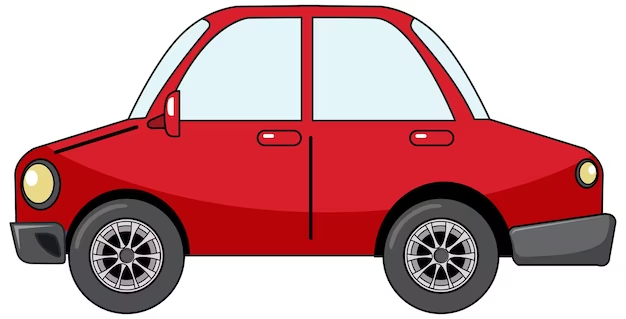

# Шаг 0: Импорты необходимых нам библиотек

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import association_metrics as am
import warnings

from urllib.parse import urlencode

from dython.nominal import associations

# шаг 3

from category_encoders.ordinal import OrdinalEncoder
from category_encoders.one_hot import OneHotEncoder
from category_encoders.target_encoder import TargetEncoder
from category_encoders.leave_one_out import LeaveOneOutEncoder

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_percentage_error as MAPE

from sklearn.pipeline import Pipeline

# шаг 4

from sklearn.preprocessing import MinMaxScaler

# шаг 5

import optuna

# шаг 6 

from catboost import CatBoostRegressor

from optuna.samplers import TPESampler

# шаг 7

from sklearn.ensemble import StackingRegressor

# шаг 8

import pickle

In [2]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)

In [3]:
warnings.filterwarnings("ignore", category=pd.errors.ChainedAssignmentError)
# or if that doesn't catch it:
warnings.filterwarnings("ignore", category=UserWarning, module="association_metrics")

# Шаг 1: Загрузка и первичный анализ данных

In [77]:
TEST = "https://www.dropbox.com/s/asf4b1z1yme5o7u/cars_test.csv?dl=1"
TRAIN = "https://www.dropbox.com/s/qk4b79i7c078sxm/cars_train.csv?dl=1"

In [76]:
data = pd.read_csv(TRAIN)

In [6]:
data.shape

(396212, 15)

In [7]:
X = data.drop('sellingprice', axis = 1)
y = data['sellingprice']

**Описание данных**

**_Признаки_**
- `year` - год производства
- `make` - производитель
- `model` - модель
- `trim` - модификация
- `body` - тип кузова
- `transmission` - тип КПП
- `vin` - идентификатор (вин)
- `state` - штат регистрации
- `condition` - состояние по шкале (1-5)
- `odometer` - пробег в милях
- `color` - цвет кузова
- `interior` - цвет интерьера
- `seller` - продавец
- `saledate` - дата продажи

**_Целевой признак_**
- `sellingprice` - стоимость продажи

In [45]:
X.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,saledate
0,2013,Dodge,Dart,Limited,Sedan,automatic,1c3cdfca5dd293552,mo,4.6,13957.0,gray,black,chrysler capital,Wed Jan 21 2015 02:30:00 GMT-0800 (PST)
1,2014,Honda,Civic,LX,Sedan,automatic,19xfb2f56ee228781,ca,5.0,2401.0,gray,black,"ahfc/honda lease trust/hvt, inc.",Thu Feb 26 2015 04:00:00 GMT-0800 (PST)
2,2012,Chevrolet,Traverse,LT,suv,automatic,1gnkrged3cj244704,wi,2.4,70046.0,white,black,capital one auto finance,Wed Jun 17 2015 03:00:00 GMT-0700 (PDT)
3,2014,Nissan,Versa Note,1.6 SV,Hatchback,automatic,3n1ce2cp9el407766,fl,2.6,23415.0,gray,black,florida auto financial group,Tue Feb 17 2015 01:30:00 GMT-0800 (PST)
4,2014,Nissan,Versa,1.6 SV,sedan,automatic,3n1cn7ap4el813308,il,3.4,17040.0,blue,black,nissan motor acceptance corporation,Thu Jun 04 2015 03:00:00 GMT-0700 (PDT)


Посмотрим на типы колонок и число пропущенных значений в них.

In [10]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 396212 entries, 0 to 396211
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          396212 non-null  int64  
 1   make          396212 non-null  str    
 2   model         396212 non-null  str    
 3   trim          396212 non-null  str    
 4   body          396212 non-null  str    
 5   transmission  396212 non-null  str    
 6   state         396212 non-null  str    
 7   condition     396212 non-null  float64
 8   odometer      396212 non-null  float64
 9   color         396212 non-null  str    
 10  interior      396212 non-null  str    
 11  seller        396212 non-null  str    
 12  saledate      396212 non-null  str    
dtypes: float64(2), int64(1), str(10)
memory usage: 39.3 MB


Посмотрим на числовые признаки

In [14]:
X.describe()

,year,condition,odometer
count,396212.000000,387759.000000,396151.000000
mean,2010.041442,3.425687,68336.479029
std,3.977384,0.949871,53559.280598
min,1982.000000,1.000000,1.000000
25%,2007.000000,2.700000,28259.000000
50%,2012.000000,3.600000,52113.000000
75%,2013.000000,4.200000,99300.000000
max,2015.000000,5.000000,999999.000000


Посмотрим на категориальные признаки

In [9]:
X.describe(include = 'str')

,make,model,trim,body,transmission,vin,state,color,interior,seller,saledate
count,388993,388922,388727,386883,350025,396212,396212,395679,395679,396212,396212
unique,91,949,1899,83,2,396212,38,20,17,12530,3544
top,Ford,Altima,Base,Sedan,automatic,1c3cdfca5dd293552,fl,black,black,nissan-infiniti lt,Tue Feb 10 2015 01:30:00 GMT-0800 (PST)
freq,66391,13969,39538,141921,337646,1,59164,78576,173230,14323,3783


Признак `vin` это уникальный идентификатор машины, поэтому удалим его.

In [8]:
X = X.drop('vin', axis = 1)

# Шаг 2: Разведочный анализ данных (EDA)

### Заполним пропуски в числовых столбцах средним значением, а в категориальных - пустой категорией

In [9]:
for c in X.columns:
    if X[c].dtype == 'string':
          X[c] = X[c].fillna("")
for c in X.columns:
    if X[c].dtype != 'string':
          mean = np.mean(X[c])
          X[c] = X[c].fillna(mean)

Посмотрим на количество значений в категориальных признаках

In [53]:
for c in X.columns:
    if X[c].dtype == 'object':
          print(c, len(X[c].unique()))

make 92
model 950
trim 1900
body 84
transmission 3
state 38
color 21
interior 18
seller 12530
date 9


В saledate очень много различных значений. Посмотрим почему.

In [18]:
X[['year', 'saledate']]

,year,saledate
0,2013,Wed Jan 21 2015 02:30:00 GMT-0800 (PST)
1,2014,Thu Feb 26 2015 04:00:00 GMT-0800 (PST)
2,2012,Wed Jun 17 2015 03:00:00 GMT-0700 (PDT)
3,2014,Tue Feb 17 2015 01:30:00 GMT-0800 (PST)
4,2014,Thu Jun 04 2015 03:00:00 GMT-0700 (PDT)
...,...,...
396207,2013,Wed Jun 17 2015 03:00:00 GMT-0700 (PDT)
396208,2009,Mon Jun 08 2015 02:00:00 GMT-0700 (PDT)
396209,2004,Tue Jan 20 2015 02:30:00 GMT-0800 (PST)
396210,2013,Fri Dec 19 2014 11:45:00 GMT-0800 (PST)


Обработаем saledate:
* сделаем признак `car_age` - возраст машины в годах
* сделаем признак `date` - месяц + год продажи машины (категориальный)

Исходный признак `saledate` удалим

In [11]:
X['car_age'] = X['saledate'].apply(lambda x: int(x.split(" ")[3])) - X['year']
X['date'] = X['saledate'].apply(lambda x: x.split(" ")[1]+x.split(" ")[3])

X = X.drop('saledate', axis=1)

### Посмотрим на матрицу корреляций числовых признаков

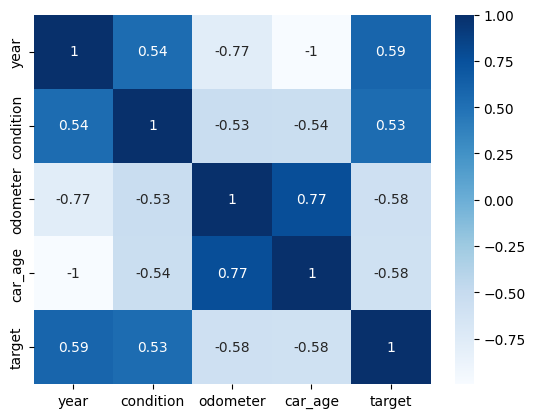

In [21]:
X['target'] = y

cols = X.columns[X.dtypes != 'string']

corr = X[cols].corr()
sns.heatmap(corr, cmap="Blues", annot=True)

X = X.drop('target', axis=1)

Все числовые признаки важны, запомним это
Также заметим, что у признака car_age единичная корреляция с таргетом => его нужно будет удалить

### Посмотрим на аналог корреляции категориальных признаков

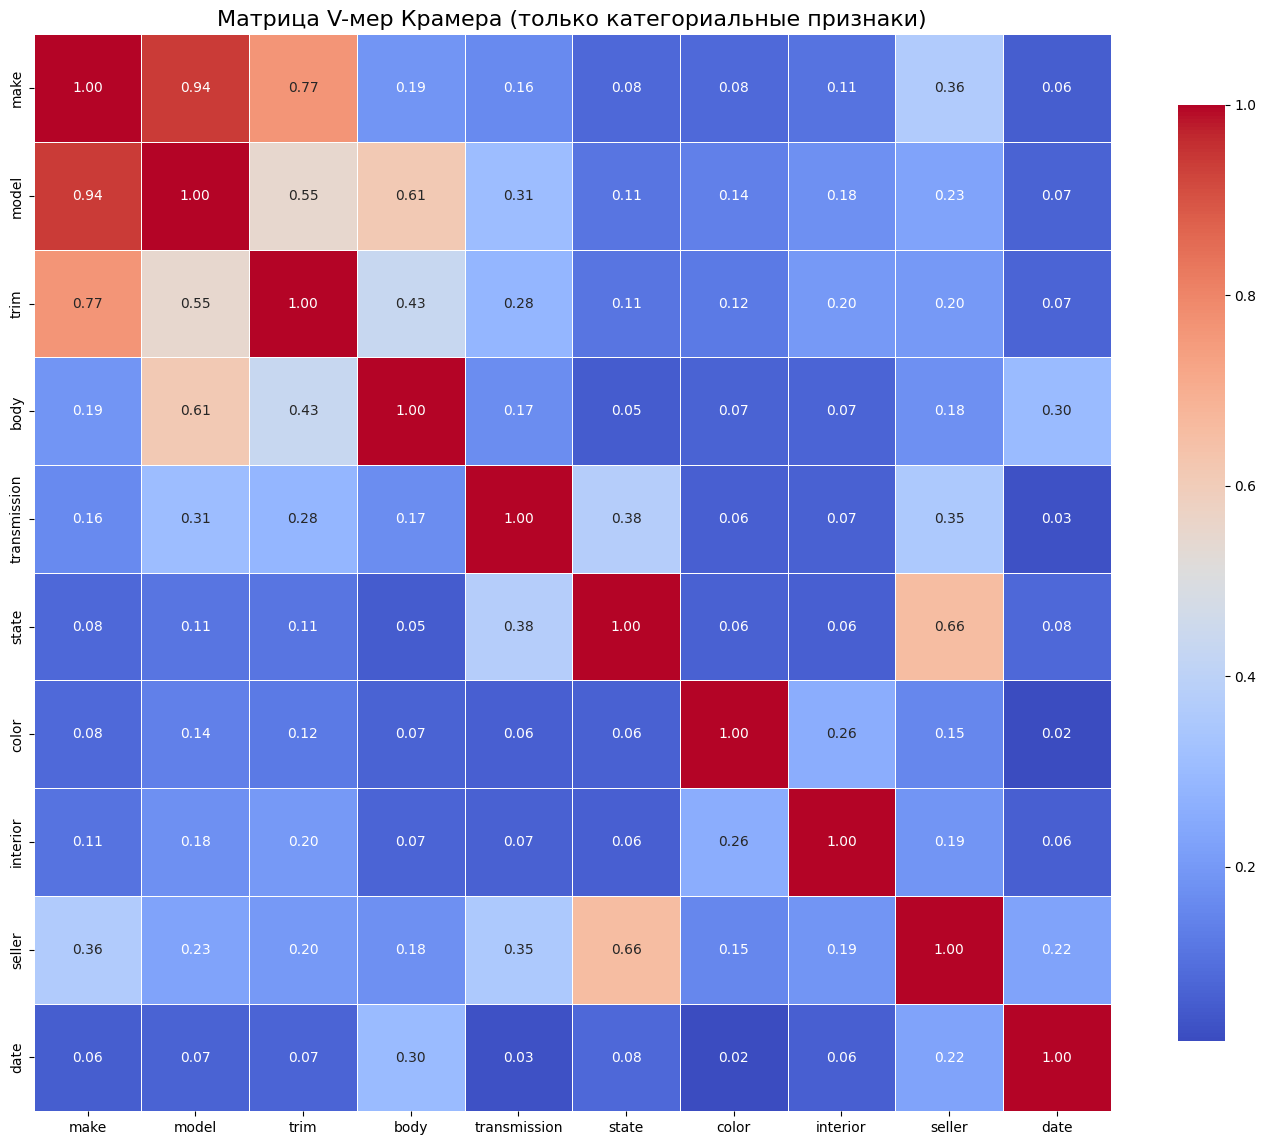

In [22]:
# Оставляем только категориальные колонки
X_cat = X.select_dtypes(include=['string'])

# Рассчёт ассоциаций только для категориальных признаков
result = associations(X_cat, nominal_columns='auto', plot=False)

# Извлечение матрицы Cramér's V
cramersv_matrix = result['corr']

# Построение тепловой карты
plt.figure(figsize=(14, 12))
sns.heatmap(
    cramersv_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Матрица V-мер Крамера (только категориальные признаки)', fontsize=16)
plt.tight_layout()
plt.show()

Заметим, что признаки make и model очень сильно связаны (V-мера Крамера = 0.94) => удалим признак make

In [12]:
X = X.drop('make', axis = 1)

### Также посмотрим на матрицу корреляций всех признаков (и числовых, и категориальных)

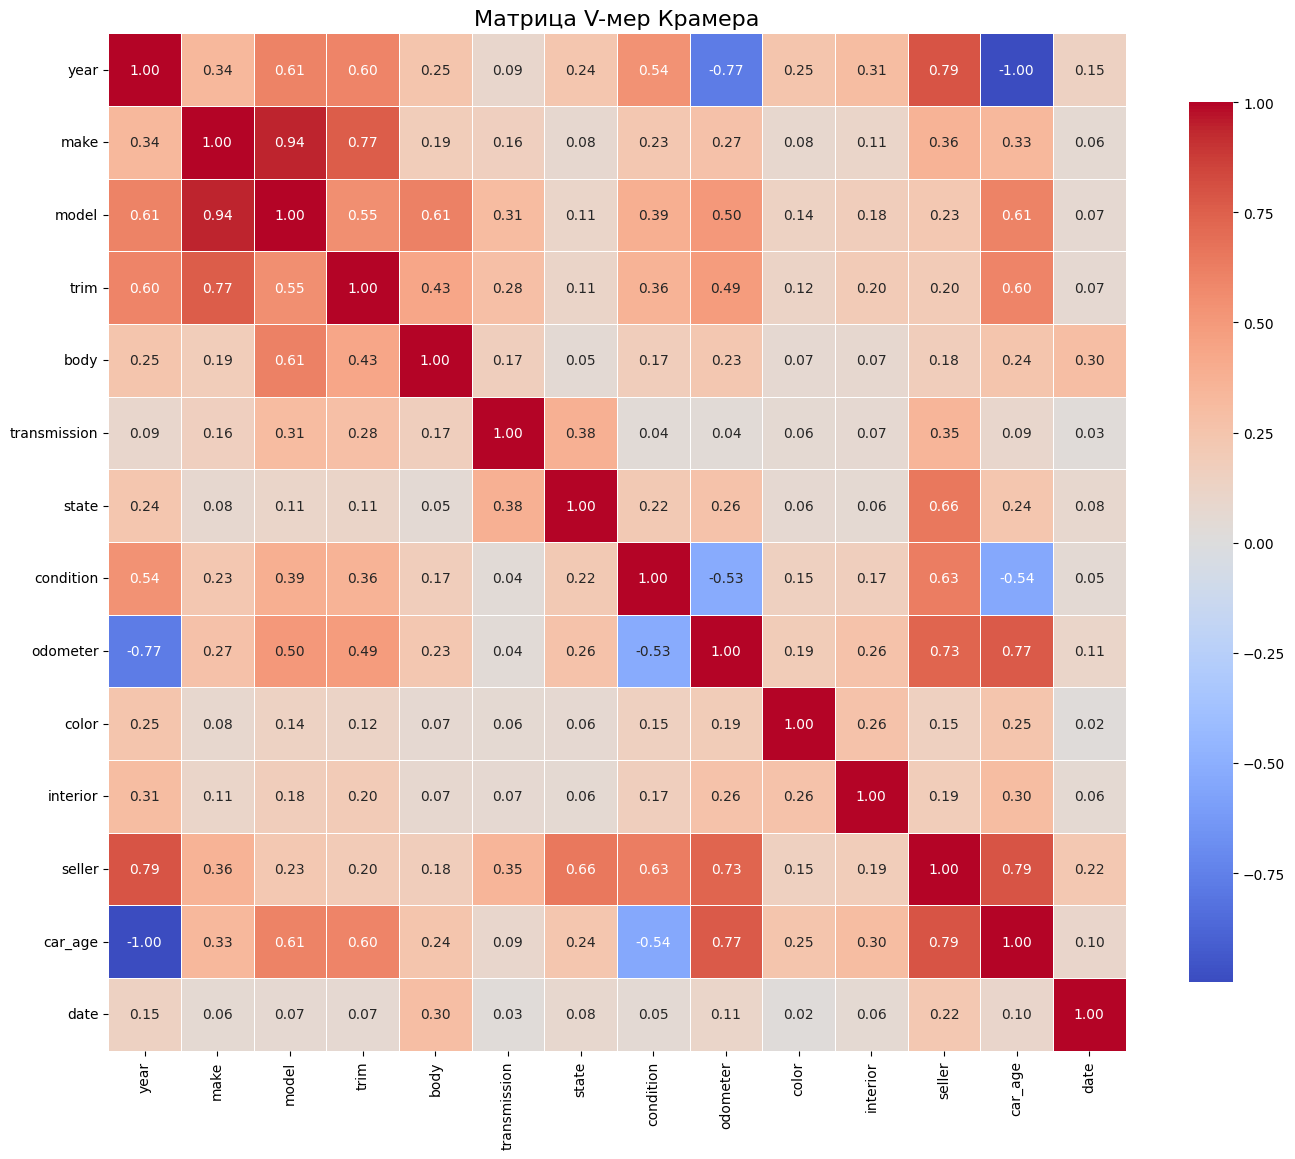

In [45]:
# Рассчёт ассоциаций
result = associations(X, nominal_columns='auto', plot=False)

# Извлечение матрицы Cramér's V
cramersv_matrix = result['corr']

# Построение тепловой карты
plt.figure(figsize=(14, 12))
sns.heatmap(
    cramersv_matrix,
    annot=True,          # показывать значения в ячейках
    fmt='.2f',            # формат чисел (2 знака после запятой)
    cmap='coolwarm',      # цветовая схема
    square=True,          # квадратные ячейки
    linewidths=0.5,       # тонкие линии между ячейками
    cbar_kws={'shrink': 0.8}  # уменьшить цветовую шкалу
)
plt.title('Матрица V-мер Крамера', fontsize=16)
plt.tight_layout()
plt.show()

### Как посмотреть влияние категориального признака на целевую переменную? Здесь лучше всего поможет scatterplot

<Axes: xlabel='None', ylabel='sellingprice'>

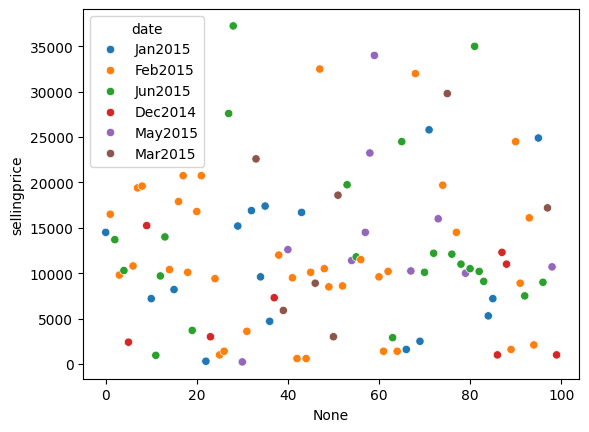

In [47]:
sns.scatterplot(data=X.iloc[:100], x=X.iloc[:100].index, y=y[:100], hue='date')

<Axes: xlabel='None', ylabel='sellingprice'>

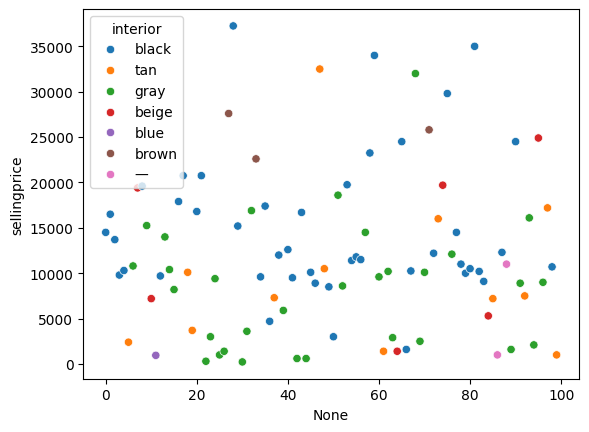

In [48]:
sns.scatterplot(data=X.iloc[:100], x=X.iloc[:100].index, y=y[:100], hue='interior')

<Axes: xlabel='None', ylabel='sellingprice'>

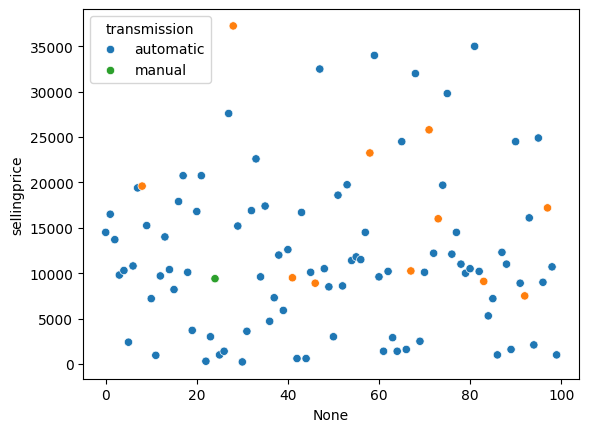

In [49]:
sns.scatterplot(data=X.iloc[:100], x=X.iloc[:100].index, y=y[:100], hue='transmission')

### Посмотрим на распределение целевой переменной

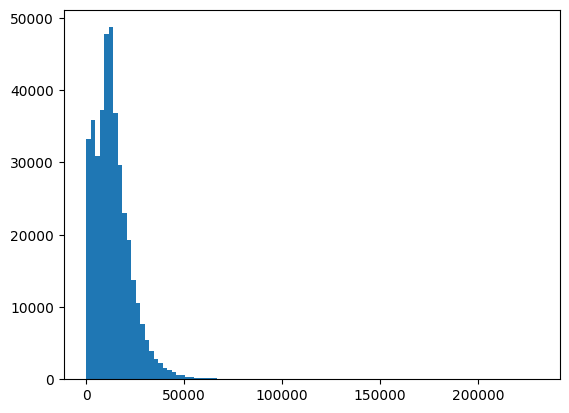

In [52]:
plt.hist(y, bins = 100); # ставим в конце ;, чтобы не выводился массив чисел

Видим, что распределение не нормальное (лог-нормальное) => скошено к 0 => skewed right

Пока мы не будем ничего делать с этим распределением, но известно, что с распределениями, отличными от нормального, большинству моделей сложно работать.

Поэтому при улучшении качества базового решения мы преобразуем это распределение.

### Поиск аномальных значений

In [13]:
cat_cols = X.columns[X.dtypes == 'string']
num_cols = X.columns[X.dtypes != 'string']

year


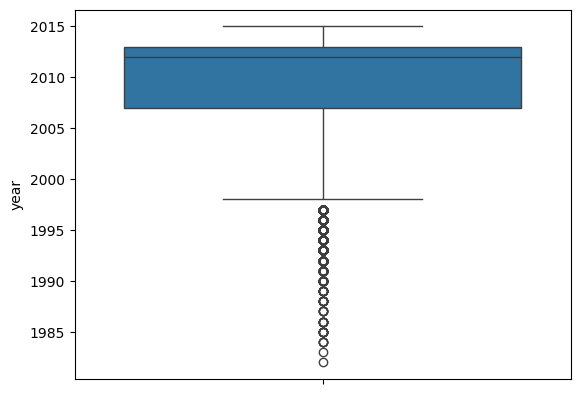

condition


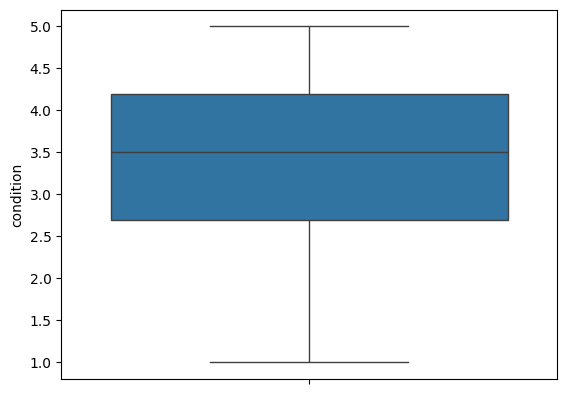

odometer


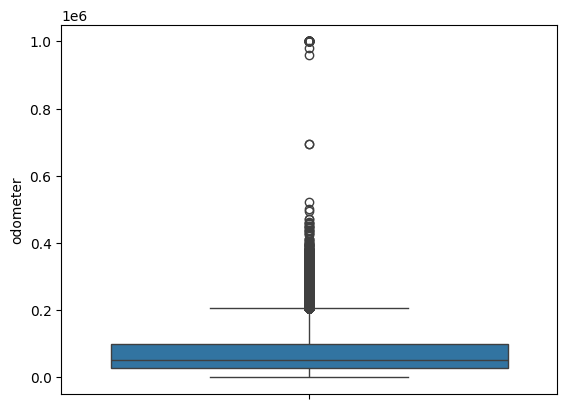

car_age


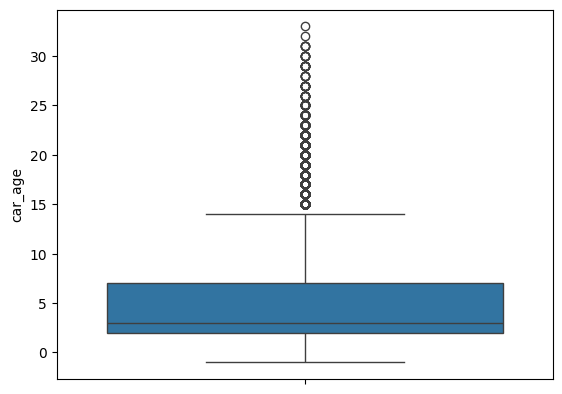

In [26]:
for col in num_cols:
    print(col)
    sns.boxplot(X[col]) # ящики с усами
    plt.show()

Этот метод нахождения аномалий хорошо работает, если признак имеет нормальное распределение. 

Если нет, то "выбросы" могут оказаться и не "выбросами".

Но для первой оценки подходит

По графикам можно сказать, что у признака `odometer` есть выбросы, остальные объясняются логически

Посмотрим на все машины(возраст, пробег), у которых пробег больше 800'000 миль

In [77]:
X[X['odometer'] > 800000][['car_age', 'odometer']]

,car_age,odometer
8651,8,999999.0
26775,8,999999.0
39643,8,999999.0
59125,8,999999.0
69969,9,999999.0
70028,10,999999.0
78649,9,999999.0
90539,14,999999.0
94884,2,999999.0
105833,8,999999.0


Выкинем машины младше 10 лет, проехавшие 1_000_000 миль - это почти точно выбросы.

In [14]:
Xnew = X[~((X.car_age < 10) & (X.odometer > 800_000))]
ynew = y[~((X.car_age < 10) & (X.odometer > 800_000))]

Xnew = Xnew.drop('car_age', axis=1);

# Шаг 3: Построение Baseline (Базового решения)
Качество 71%

Для baseline-модели мы сделаем следующее:
* закодируем категориальные признаки при помощи TargetEncoder
* масштабируем все признаки с помощью StandardScaler
* обучим линейную регрессию

### Разобьем данные на train и test 

In [24]:
Xtrain, Xtest, ytrain, ytest = train_test_split(Xnew, ynew, test_size=0.25, random_state=42)

### Осуществим задуманные шаги

In [25]:
enc = TargetEncoder(cols = cat_cols)
enc.fit(Xtrain, ytrain)
Xtrain_new = enc.transform(Xtrain)
Xtest_new = enc.transform(Xtest)

scaler = StandardScaler()
scaler.fit(Xtrain_new)
Xtrain_new = pd.DataFrame(scaler.transform(Xtrain_new), columns=Xtrain.columns)
Xtest_new = pd.DataFrame(scaler.transform(Xtest_new), columns=Xtest.columns)

model = LinearRegression()
model.fit(Xtrain_new, ytrain)
pred = model.predict(Xtest_new)

### Оценим качество полученной модели

In [26]:
MAPE(ytest, pred)

0.7151865211266948

Ошибка в среднем 71% от цены - модель пока не очень хорошая, есть куда улучшать!

## Pipeline

In [27]:
p1 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

In [28]:
p1.fit(Xtrain, ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('encoder_', ...), ('scaler_', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,Index(['model... dtype='str')
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [29]:
pred_p1 = p1.predict(Xtest)

MAPE(ytest, pred_p1)

0.7151865211266948

## Итого получили качество 71%

# Шаг 4: Первые улучшения модели
Качество 21%

В нашем пайплайне три шага:
* закодируем категориальные признаки при помощи TargetEncoder
* масштабируем все признаки с помощью StandardScaler
* обучим линейную регрессию

Как можно улучшить решение?

1) Можно подобрать гиперпараметры кодировщика в шаге 1, а также сам кодировщик

2) Можно использовать другой способ масштабирования данных

3) Можно использовать другую модель!

In [30]:
# по умолчанию smoothing = 10

p2 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols, smoothing = 1)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

p3 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols, smoothing = 100)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

p4 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols, smoothing = 1)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

p5 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols, smoothing = 10)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

p6 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols, smoothing = 100)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

p7 = Pipeline([
    ('encoder_', LeaveOneOutEncoder(cols = cat_cols)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

p8 = Pipeline([
    ('encoder_', LeaveOneOutEncoder(cols = cat_cols)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

In [31]:
for i,p in enumerate([p1,p2,p3,p4,p5,p6,p7,p8]):
    p.fit(Xtrain, ytrain)
    pred = p.predict(Xtest)
    print(i+1, MAPE(ytest, pred))

1 0.7151865211266948
2 0.720747198188984
3 0.7246917683308362
4 0.7207471981889945
5 0.7151865211266902
6 0.7246917683308265
7 0.7217788610751672
8 0.7217788610751674


Значительных улучшений нет.

Сменим теперь модель

In [32]:
p9 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols)),
    ('scaler_', StandardScaler()),
    ('model_', RandomForestRegressor(n_jobs=-1))
])

p9.fit(Xtrain, ytrain)
pred = p9.predict(Xtest)
print(9, MAPE(ytest, pred))

9 0.2135104110778515


Уже гораздо лучше. Попробуем для **RandomForest** поменять кодировщик, его гиперпараметры и скалер.

In [33]:
p10 = Pipeline([
    ('encoder_', LeaveOneOutEncoder(cols = cat_cols)),
    ('scaler_', StandardScaler()),
    ('model_', RandomForestRegressor(n_jobs=-1))
])

p11 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols)),
    ('scaler_', MinMaxScaler()),
    ('model_', RandomForestRegressor(n_jobs=-1))
])

p12 = Pipeline([
    ('encoder_', LeaveOneOutEncoder(cols = cat_cols)),
    ('scaler_', MinMaxScaler()),
    ('model_', RandomForestRegressor(n_jobs=-1))
])

p13 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols, smoothing = 1)),
    ('scaler_', StandardScaler()),
    ('model_', RandomForestRegressor(n_jobs=-1))
])

In [34]:
for i,p in enumerate([p9,p10,p11,p12,p13]):
    p.fit(Xtrain.iloc[:50000], ytrain.iloc[:50000])
    pred = p.predict(Xtest)
    print(i+9, MAPE(ytest, pred))

9 0.3349393474622364
10 1.9452849384350401
11 0.31762659194245835
12 1.9503012205928056
13 0.3356235960684135


Посмотрим на важность признаков

In [35]:
weights = pd.DataFrame(
    p9['model_'].feature_importances_,
    index = Xtrain.columns
).sort_values(
    by = 0,
    ascending = False
)

weights

,0
model,0.370614
odometer,0.359190
year,0.082290
trim,0.062094
seller,0.052499
body,0.023345
condition,0.021125
state,0.008006
color,0.006681
interior,0.006143


## Итого получили качество 21% (качество baseline 71%)

# Шаг 5: Дальнейшие улучшения решения
Качество 19%

## `1`

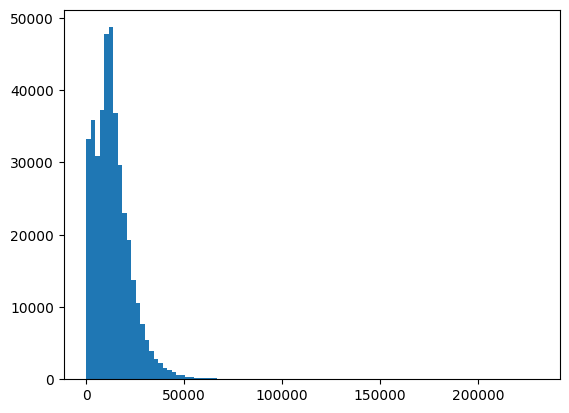

In [36]:
plt.hist(y, bins = 100);

Попробуем сделать распределение целевой переменной более похожим на нормальное и заново обучить лучшую модель с предыдущего шага

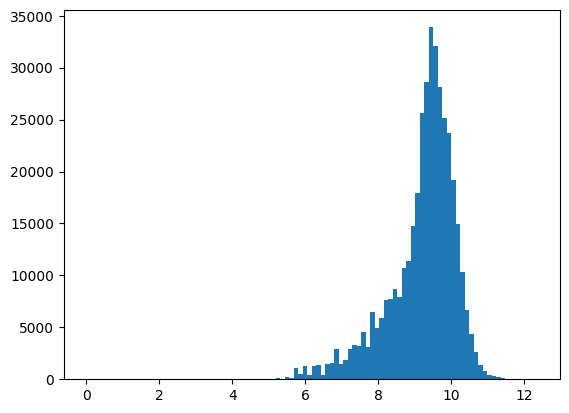

In [37]:
plt.hist(np.log(y), bins = 100);

In [38]:
ytrain = np.log(ytrain)
ytest = np.log(ytest)

Т. к. мы делали преобразование целевой функции, когда мы считаем ошибку модели, мы должны сделать обратное преобразование

In [64]:
p9 = Pipeline([
    ('encoder_', TargetEncoder(cols = cat_cols)),
    ('scaler_', StandardScaler()),
    ('model_', RandomForestRegressor(n_jobs=-1))
])

p9.fit(Xtrain, ytrain)
pred_p9 = p9.predict(Xtest)
print(MAPE(np.exp(ytest), np.exp(pred)))  

0.18937900085927745


Качество модели возросло: было 20%, сейчас 19%

## `2`

Подберем оптимальные параметры леса при помощи **Optuna**

In [92]:
data_pipeline = Pipeline([
        ('encoder_',TargetEncoder(cols=cat_cols)), 
        ('scaler_', StandardScaler())
]) 

Xtrain_good = data_pipeline.fit_transform(Xtrain, ytrain)
Xtest_good = data_pipeline.transform(Xtest)

In [60]:
def objective(trial):    

    param = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 1000)
        #"max_features": trial.suggest_categorical("max_features", ['sqrt', 'log2', None])
    }

    estimator = RandomForestRegressor(**param, verbose=False, n_jobs=-1)

    estimator.fit(Xtrain_good, ytrain)
    pred = estimator.predict(Xtest_good)

    return MAPE(np.exp(ytest), np.exp(pred))

sampler = TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=100)
print(study.best_trial)

[I 2026-03-18 16:00:43,451] A new study created in memory with name: no-name-7e342b35-6678-4fd5-9812-6f2b2c5a2cd0
[I 2026-03-18 16:01:46,060] Trial 0 finished with value: 0.18614682556003395 and parameters: {'n_estimators': 381}. Best is trial 0 with value: 0.18614682556003395.
[W 2026-03-18 16:04:12,428] Trial 1 failed with parameters: {'n_estimators': 952} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\1\anaconda3\envs\py12\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\1\AppData\Local\Temp\ipykernel_10316\3962835666.py", line 10, in objective
    estimator.fit(Xtrain_good, ytrain)
  File "C:\Users\1\anaconda3\envs\py12\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\1\anaconda3\envs\py12\Lib\sit

KeyboardInterrupt: 

In [56]:
study.best_params

{'n_estimators': 164, 'max_features': None}

In [58]:
model = RandomForestRegressor(n_estimators=27, n_jobs=-1)

model.fit(Xtrain_good, ytrain)
pred = model.predict(Xtest_good)
MAPE(np.exp(ytest), np.exp(pred))

0.18834875086101419

## Итого получили качество 18% (пред. лучшее качество 21%)

# Шаг 6: Улучшаем модель дальше
Качество 17%

Попробуем CatBoost

In [45]:
model = CatBoostRegressor()

model.fit(Xtrain_good, ytrain, logging_level='Silent')
pred = model.predict(Xtest_good)

MAPE(np.exp(ytest), np.exp(pred))

0.18851937358986648

In [59]:
def objective(trial):    

    param = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 1000),
        "max_depth": trial.suggest_int("max_depth", 2, 16)
    }

    estimator = CatBoostRegressor(**param, verbose=False)

    estimator.fit(Xtrain_good[:50000], ytrain.iloc[:50000])
    pred = estimator.predict(Xtest_good)

    return MAPE(np.exp(ytest), np.exp(pred))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)
print(study.best_trial)

[I 2026-03-17 19:11:36,121] A new study created in memory with name: no-name-110fcb24-10d2-4df8-ae1c-b94ba71b7c7e
[I 2026-03-17 19:11:37,790] Trial 0 finished with value: 0.21358135898430403 and parameters: {'n_estimators': 413, 'max_depth': 6}. Best is trial 0 with value: 0.21358135898430403.
[I 2026-03-17 19:11:38,202] Trial 1 finished with value: 0.21157724236505562 and parameters: {'n_estimators': 92, 'max_depth': 7}. Best is trial 1 with value: 0.21157724236505562.
[I 2026-03-17 19:18:22,687] Trial 2 finished with value: 0.22269286793917897 and parameters: {'n_estimators': 488, 'max_depth': 16}. Best is trial 1 with value: 0.21157724236505562.
[I 2026-03-17 19:19:14,701] Trial 3 finished with value: 0.19920823517192598 and parameters: {'n_estimators': 826, 'max_depth': 12}. Best is trial 3 with value: 0.19920823517192598.
[I 2026-03-17 19:19:16,337] Trial 4 finished with value: 0.22080289624007676 and parameters: {'n_estimators': 447, 'max_depth': 4}. Best is trial 3 with value: 0

FrozenTrial(number=12, state=<TrialState.COMPLETE: 1>, values=[0.19132498904555303], datetime_start=datetime.datetime(2026, 3, 17, 19, 22, 2, 573441), datetime_complete=datetime.datetime(2026, 3, 17, 19, 22, 13, 680654), params={'n_estimators': 1000, 'max_depth': 9}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=10, step=1), 'max_depth': IntDistribution(high=16, log=False, low=2, step=1)}, trial_id=12, value=None)


In [60]:
print(study.best_params)

{'n_estimators': 1000, 'max_depth': 9}


In [95]:
model = CatBoostRegressor(n_estimators = 477, max_depth = 11) # это наша модель основная

model.fit(Xtrain_good, ytrain, logging_level='Silent')
pred_cb = model.predict(Xtest_good)
MAPE(np.exp(ytest), np.exp(pred_cb))

0.17039958909106248

Получили качество 17%

Теперь пусть CatBoost сам кодирует категориальные признаки

In [63]:
Xtrain.info()

<class 'pandas.DataFrame'>
Index: 297137 entries, 82213 to 121967
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          297137 non-null  int64  
 1   model         297137 non-null  str    
 2   trim          297137 non-null  str    
 3   body          297137 non-null  str    
 4   transmission  297137 non-null  str    
 5   state         297137 non-null  str    
 6   condition     297137 non-null  float64
 7   odometer      297137 non-null  float64
 8   color         297137 non-null  str    
 9   interior      297137 non-null  str    
 10  seller        297137 non-null  str    
 11  date          297137 non-null  str    
dtypes: float64(2), int64(1), str(9)
memory usage: 29.5 MB


In [47]:
cat_cols_indices = np.where(Xtrain.dtypes == 'string')[0]

In [48]:
cat_cols_indices

array([ 1,  2,  3,  4,  5,  8,  9, 10, 11])

In [49]:
model = CatBoostRegressor(cat_features=cat_cols_indices)

model.fit(Xtrain, ytrain, logging_level='Silent')
pred_cb = model.predict(Xtest)
MAPE(np.exp(ytest), np.exp(pred_cb))

0.17665298653524664

# Шаг 7: Stacking и Blending

### Простое смешивание

* RandomForest - 0.189
* CatBoost - 0.170

In [70]:
pred_final = 0.3 * pred_p9 + 0.7 * pred_cb

MAPE(np.exp(ytest), np.exp(pred_final))

0.16961037672809093

### Stacking

In [72]:
estimators = [
    ('rf', RandomForestRegressor(n_jobs=-1)),
    ('cb', CatBoostRegressor(n_estimators = 477, max_depth = 11))
]

reg = StackingRegressor(
    estimators=estimators,
    final_estimator=RandomForestRegressor(n_estimators=10, random_state=42)
)

reg.fit(Xtrain_good, ytrain)
pred_stacking = reg.predict(Xtest_good)

MAPE(np.exp(ytest), np.exp(pred_stacking))

Learning rate set to 0.183769
0:	learn: 0.7899825	total: 48.6ms	remaining: 23.1s
1:	learn: 0.6832326	total: 96.6ms	remaining: 23s
2:	learn: 0.5997472	total: 142ms	remaining: 22.5s
3:	learn: 0.5350876	total: 189ms	remaining: 22.4s
4:	learn: 0.4845264	total: 237ms	remaining: 22.4s
5:	learn: 0.4453096	total: 285ms	remaining: 22.4s
6:	learn: 0.4162230	total: 333ms	remaining: 22.3s
7:	learn: 0.3936800	total: 380ms	remaining: 22.3s
8:	learn: 0.3766028	total: 426ms	remaining: 22.1s
9:	learn: 0.3630786	total: 474ms	remaining: 22.1s
10:	learn: 0.3533589	total: 519ms	remaining: 22s
11:	learn: 0.3446474	total: 575ms	remaining: 22.3s
12:	learn: 0.3376677	total: 626ms	remaining: 22.3s
13:	learn: 0.3322356	total: 680ms	remaining: 22.5s
14:	learn: 0.3277302	total: 729ms	remaining: 22.4s
15:	learn: 0.3244077	total: 776ms	remaining: 22.4s
16:	learn: 0.3217219	total: 823ms	remaining: 22.3s
17:	learn: 0.3194727	total: 871ms	remaining: 22.2s
18:	learn: 0.3173098	total: 920ms	remaining: 22.2s
19:	learn: 0.

0.192664488758571

В данном случае стекинг нам не помог (простое смешивание выдает качество лучше)

# Шаг 8: Получение предсказания и интерпретация результатов

### Сохранение результатов
Что сохраняем?
+ Предсказания моделей
+ Модели

In [87]:
test_data = pd.read_csv(TEST)

test_data.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,saledate
0,2011,Chevrolet,HHR,LT,Wagon,automatic,3gnbabfwxbs592572,ny,2.5,99177.0,silver,gray,credit acceptance corp/vrs/southfield,Thu Feb 26 2015 01:15:00 GMT-0800 (PST)
1,2008,Ford,Econoline Cargo,E-150,Van,automatic,1ftne14w28db27123,mn,2.8,131850.0,white,gray,ari,Thu Jan 22 2015 02:45:00 GMT-0800 (PST)
2,2013,Chrysler,200,Touring,Sedan,automatic,1c3ccbbbxdn678363,tn,3.9,43643.0,—,gray,enterprise veh exchange/rental,Wed Feb 25 2015 02:30:00 GMT-0800 (PST)
3,2013,Hyundai,Elantra,GLS,Sedan,automatic,5npdh4ae7dh257662,la,3.2,59294.0,white,beige,the hertz corporation,Wed Dec 31 2014 10:00:00 GMT-0800 (PST)
4,2012,Ford,Explorer,Limited,SUV,automatic,1fmhk8f83cga78501,nj,2.5,39311.0,gray,black,"ford motor credit company,llc",Wed Feb 04 2015 01:00:00 GMT-0800 (PST)


Заполняем пропуски

In [88]:
for c in test_data.columns:
    if test_data[c].dtype == 'string':
          test_data[c] = test_data[c].fillna("")
for c in test_data.columns:
    if test_data[c].dtype != 'string':
          mean = np.mean(X[c])
          test_data[c] = test_data[c].fillna(mean)

Обрабатываем дату

In [89]:
test_data['date'] = test_data['saledate'].apply(lambda x: x.split(" ")[1]+x.split(" ")[3])

Удаляем столбцы 

In [90]:
test_data = test_data.drop(['vin', 'make', 'saledate'], axis = 1)

Преобразуем данные перед применением модели

In [93]:
test_good = data_pipeline.transform(test_data)

Применяем модель

In [96]:
test_pred = model.predict(test_good)

Сохраняем предсказания в файл

In [97]:
test_data['prediction'] = test_pred

test_data['prediction'].to_csv("test_prediction.csv", index = False)

### Сохранение модели

In [101]:
with open('model.pickle', 'wb') as f:
    pickle.dump(model, f)

In [103]:
# а так модель можно загрузить из файла:
with open('model.pickle', 'rb') as f:
    model = pickle.load(f)